In [1]:
using Random:rand
using Printf: @sprintf, @printf
using Printf: @sprintf as @s
using LinearAlgebra: eigen, inv, pinv, diag, Diagonal, mul!
import LinearAlgebra.BLAS
using Statistics: mean, std
import CairoMakie
using CairoMakie: Figure, Axis, scatter!, lines!, save, errorbars!, errorbars, Cycled, axislegend, Label, ylims!
using CairoMakie: set_theme!, theme_latexfonts, update_theme!, rich
using CairoMakie: Relative, translate!
using CairoMakie: WilkinsonTicks
using LaTeXStrings: latexstring, @L_str
# import Logging: @warn
# using StyledStrings: @styled_str
import HDF5

In [2]:
BLAS.set_num_threads(1)

In [3]:
CairoMakie.theme(:fonts)

Attributes with 4 entries:
  bold => TeX Gyre Heros Makie Bold
  bold_italic => TeX Gyre Heros Makie Bold Italic
  italic => TeX Gyre Heros Makie Italic
  regular => TeX Gyre Heros Makie

In [4]:
fig_path = "summary_figs"
mkpath(fig_path)
plot_prefix = "phi4_m0p5_lamb16"

set_theme!(theme_latexfonts())

In [5]:
CairoMakie.theme(:fonts)

Attributes with 5 entries:
  bold => FTFont (family = NewComputerModern, style = 10 Bold)
  bold_italic => TeX Gyre Heros Makie Bold Italic
  bolditalic => FTFont (family = NewComputerModern, style = 10 Bold Italic)
  italic => FTFont (family = NewComputerModern, style = 10 Italic)
  regular => FTFont (family = NewComputerModern Math, style = Regular)

In [6]:
update_theme!(;
    fontsize = 24,          # base font size for everything
    Axis = (
        titlesize      = 26,
        titlefont      = :bold,
        xlabelsize     = 24,
        ylabelsize     = 24,
        xticklabelsize = 18,
        yticklabelsize = 18,
    ),
    Legend = (
        labelsize  = 24,
    ),
)

In [7]:
const a_0 = 0.05 # in units of a
const m   = 0.5
subtract_ratio = 1.0
const epsilon = 0.01

0.01

In [8]:
Ns_list = 4:4:32

4:4:32

In [9]:
n = length(Ns_list)

energy_unmodified_ls       = Vector{Float64}(undef, n)
energy_unmodified_delta_ls = Vector{Float64}(undef, n)
phi2max_unmodified_ls      = Vector{Float64}(undef, n)
energy_phi2_ls             = Vector{Float64}(undef, n)
energy_phi2_delta_ls       = Vector{Float64}(undef, n)
phi2max_phi2_ls            = Vector{Float64}(undef, n)
phi2max_phi2_delta_ls      = Vector{Float64}(undef, n)

phi2mean_unmodified_ls     = Vector{Float64}(undef, n)

output_path = "output"
for (i, Ns) in enumerate(Ns_list)
    name = "phi4_norm_ns$(Ns)"
    data_name = joinpath(output_path, name * ".h5")
    HDF5.h5open(data_name, "r") do f
        @assert a_0 ≈ HDF5.read(f["parameters/a_0"])
        @assert m   ≈ HDF5.read(f["parameters/m"])

        energy_unmodified_ls[i]       = HDF5.read(f["unmodified/energy_mean"])
        energy_unmodified_delta_ls[i] = HDF5.read(f["unmodified/energy_delta"])
        phi2max_unmodified_ls[i]      = HDF5.read(f["unmodified/phi2max"])
        energy_phi2_ls[i]             = HDF5.read(f["phi2/energy_mean"])
        energy_phi2_delta_ls[i]       = HDF5.read(f["phi2/energy_delta"])
        phi2max_phi2_ls[i]            = HDF5.read(f["phi2/phi2max_mean"])
        phi2max_phi2_delta_ls[i]      = HDF5.read(f["phi2/phi2max_delta"])

        phi2mean_unmodified_ls[i]     = mean(HDF5.read(f["unmodified/phi2_mean"])) # this would be Ns*Ns array, but let's just average over it for simplicity
    end
end

In [10]:
function phi2bound_from_energy(energy; m=m, subtract_ratio=subtract_ratio)
    return energy * 2  / subtract_ratio / m^2
end

function energy_from_phi2(phi2; m=m, subtract_ratio=subtract_ratio)
    return phi2 / 2 * m^2 * subtract_ratio
end

energy_from_phi2 (generic function with 1 method)

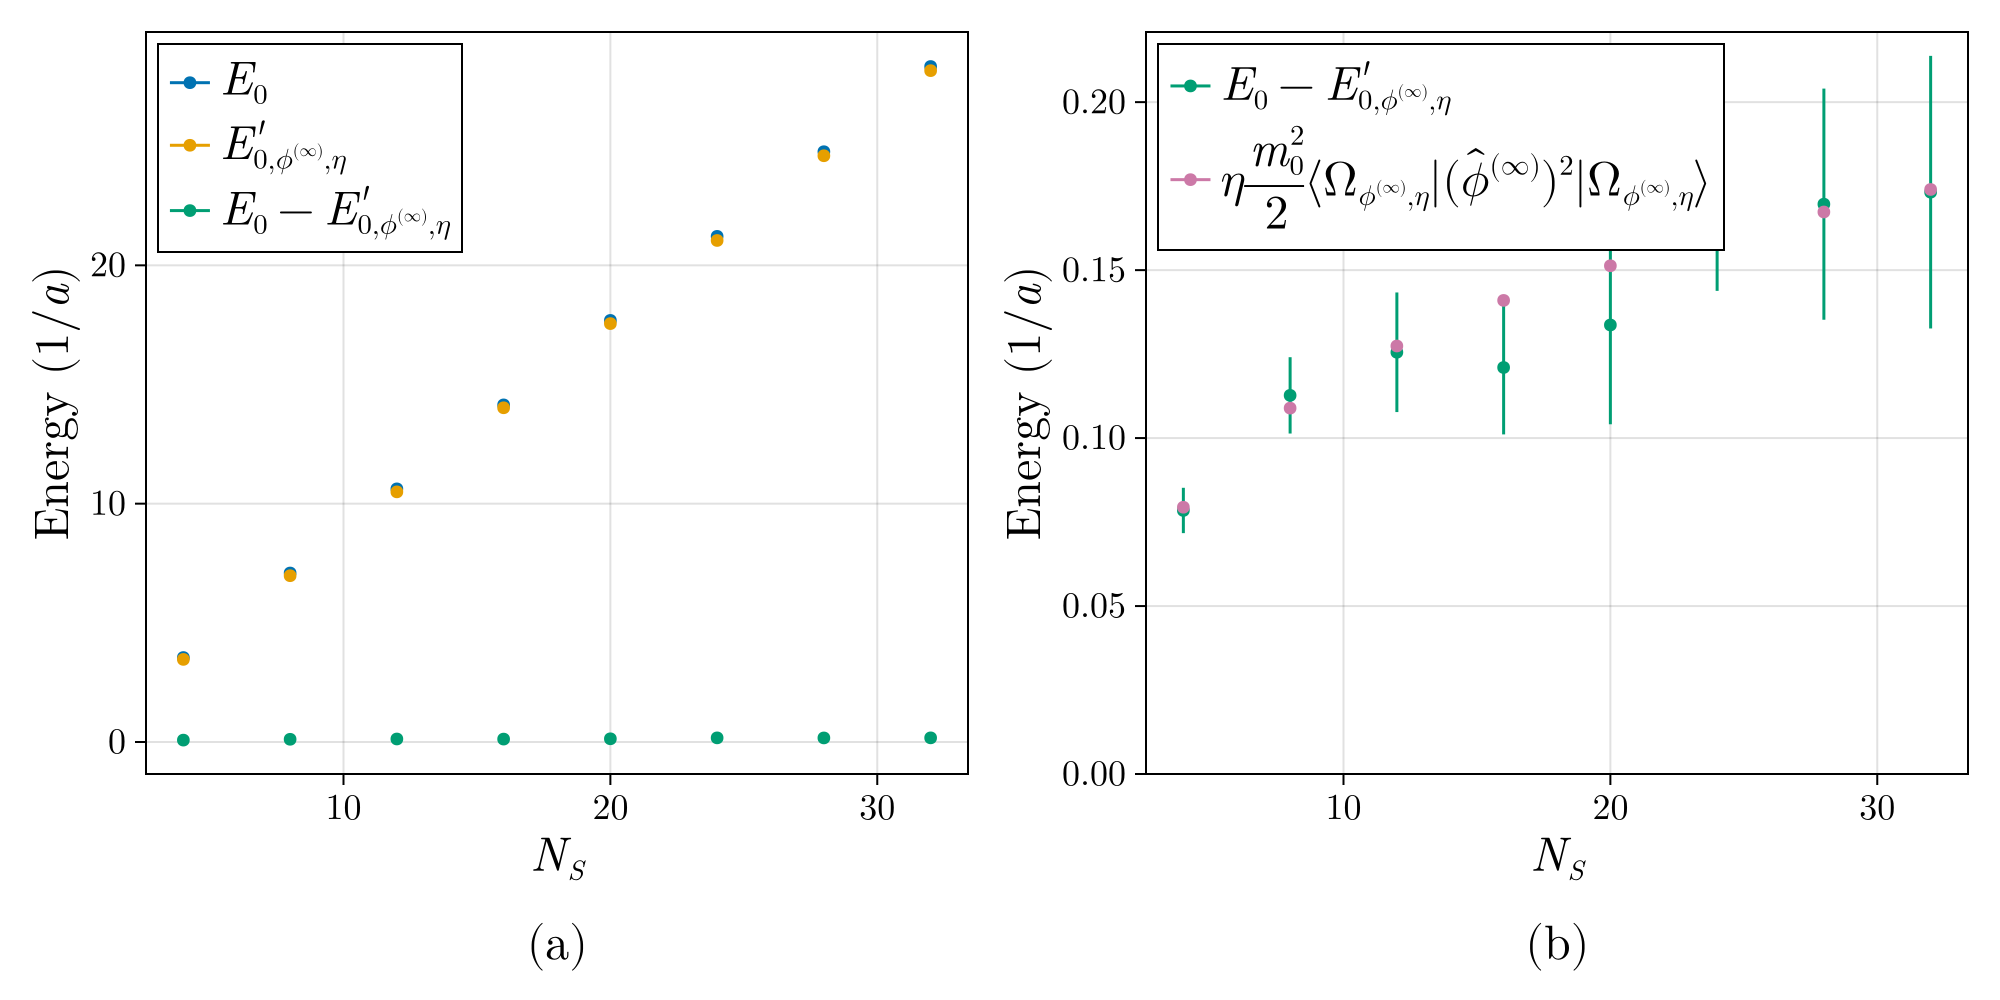

In [11]:
e_phi2max_phi2       = energy_from_phi2(phi2max_phi2_ls)
e_phi2max_phi2_delta = energy_from_phi2(phi2max_phi2_delta_ls)
e_phi2max_legend = L"\eta\frac{m_0^2}{2}\langle\Omega_{\phi^{(\infty)},\eta}|(\hat{\phi}^{(\infty)})^2 | \Omega_{\phi^{(\infty)},\eta}\rangle"

f = Figure(;size=(1000, 500))
ax1 = Axis(f[1, 1]; xlabel=L"N_S", ylabel=L"Energy ($1/a$)")

scatter!(ax1, Ns_list, energy_unmodified_ls; label=L"E_0")
errorbars!(ax1, Ns_list, energy_unmodified_ls, energy_unmodified_delta_ls, label=L"E_0")
scatter!(ax1, Ns_list, energy_phi2_ls; label=L"E'_{0,\phi^{(\infty)},\eta}")
errorbars!(ax1, Ns_list, energy_phi2_ls, energy_phi2_delta_ls; label=L"E'_{0,\phi^{(\infty)},\eta}")
scatter!(ax1, Ns_list, energy_unmodified_ls .- energy_phi2_ls; label=L"E_0 - E'_{0,\phi^{(\infty)},\eta}")
errorbars!(ax1, Ns_list, energy_unmodified_ls .- energy_phi2_ls, hypot.(energy_unmodified_delta_ls, energy_phi2_delta_ls); label=L"E_0 - E'_{0,\phi^{(\infty)},\eta}")

axislegend(ax1; position= :lt, merge=true)


ax2 = Axis(f[1, 2]; xlabel=L"N_S", ylabel=L"Energy ($1/a$)")
ylims!(ax2, (0, nothing))
scatter!(ax2, Ns_list, energy_unmodified_ls .- energy_phi2_ls; label=L"E_0 - E'_{0,\phi^{(\infty)},\eta}", color=Cycled(3))
errorbars!(ax2, Ns_list, energy_unmodified_ls .- energy_phi2_ls, hypot.(energy_unmodified_delta_ls, energy_phi2_delta_ls); 
    label=L"E_0 - E'_{0,\phi^{(\infty)},\eta}", color=Cycled(3))
scatter!(ax2, Ns_list, e_phi2max_phi2; label = e_phi2max_legend, color=Cycled(4))
errorbars!(ax2, Ns_list, e_phi2max_phi2, e_phi2max_phi2_delta; label = e_phi2max_legend, color=Cycled(4))
axislegend(ax2; position= :lt, merge=true)

Label(f[2, 1], "(a)"; tellwidth=false)
Label(f[2, 2], "(b)"; tellwidth=false)



f

Let's denote the original Hamiltonian by $H_0$. And denote the modified Hamiltonian as $H_\phi$. We know $H_\phi=H_0 - \eta \frac{1}{2 } m^2 \phi_\text{max}^2$, where $\eta$ is a constant (set to be $1/2$ in my code).

Then, let's denote the difference in ground state energy as $\Delta E_0$.

Now, let's deal with the quantity $\frac{1}{\eta} \frac{2}{m^2} \Delta E_0$. This is closely related to the bound on $\bra{\psi} \phi_\text{max}^2 \ket{\psi}$.

In fact, (now we are in the unmodified theory) suppose we have state $\ket{\psi}$ that has energy $E_\text{free}$ over the vacuum. We know $\bra{\psi} \phi_\text{max}^2 \ket{\psi}$ is bounded by $\frac{1}{\eta} \frac{2}{m^2} \left(\Delta E_0+E_\text{free}\right)$.

(By the way, we in fact have $\bra{\Omega_0} \phi_\text{max}^2 \ket{\Omega_0}\leq \frac{1}{\eta} \frac{2}{m^2} \Delta E_0 \leq \bra{\Omega_\phi} \phi_\text{max}^2 \ket{\Omega_\phi}$, where $\ket{\Omega_0}$ is the vacuum in unmodified Hamiltonian, while $\ket{\Omega_\phi}$ is the vacuum for $H_B$.)

Now, let's plot $\frac{1}{\eta} \frac{2}{m^2} \Delta E_0$ to get an intuitive sense of the magnitude.

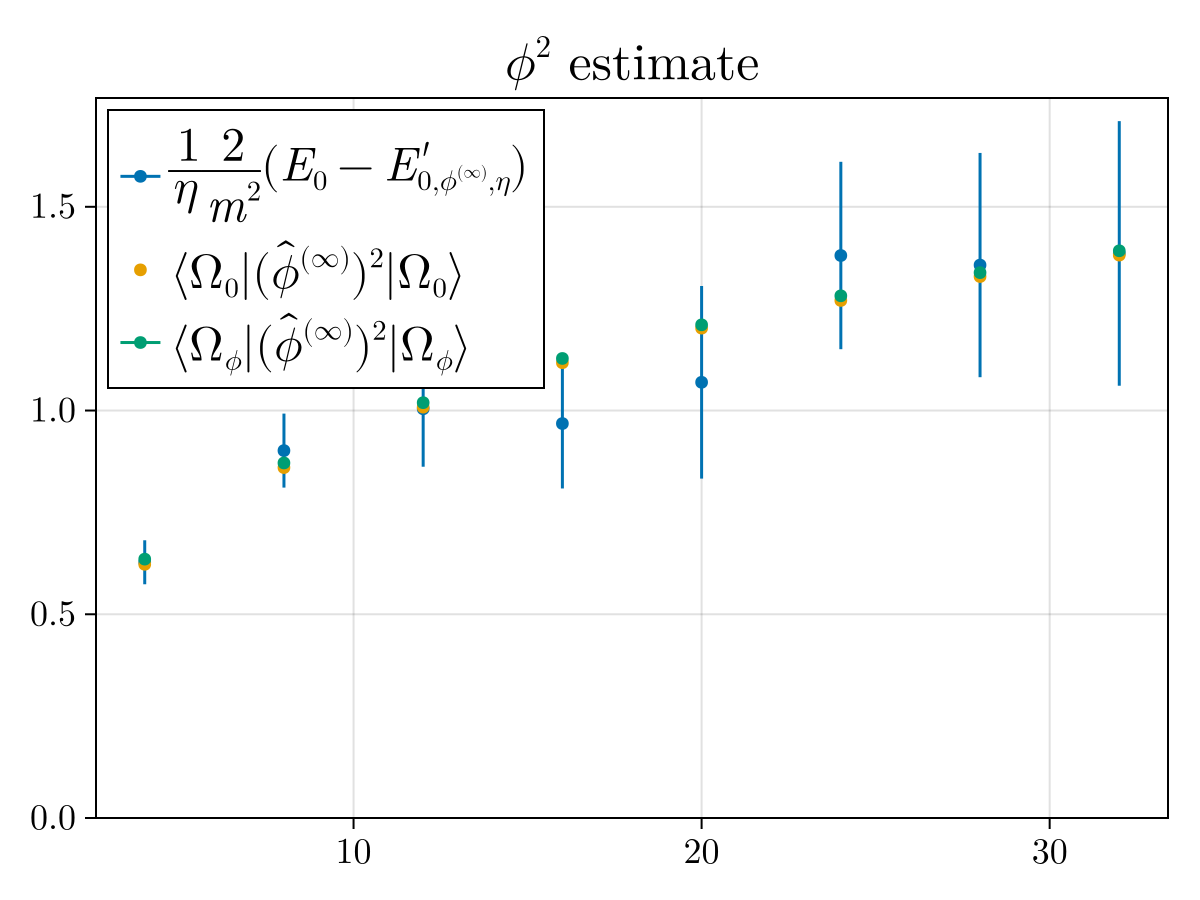

In [12]:
f = Figure()
ax = Axis(f[1, 1], title=L"$\phi^2$ estimate")
ylims!(ax, (0, nothing))

phi2_naive_est = phi2bound_from_energy.(energy_unmodified_ls)
phi2_naive_est_delta = phi2bound_from_energy.(energy_unmodified_delta_ls) # since this is a linear function

phi2_est = phi2bound_from_energy.(energy_unmodified_ls .- energy_phi2_ls)
phi2_est_delta = phi2bound_from_energy.(hypot.(energy_unmodified_delta_ls, energy_phi2_delta_ls)) # since this is a linear function

ylabel_u = L"\langle \Omega_\phi | (\hat{\phi}^{(\infty)})^2 | \Omega_\phi \rangle"
ylabel_l = L"\langle \Omega_0    | (\hat{\phi}^{(\infty)})^2 | \Omega_0     \rangle"


scatter!(ax, Ns_list, phi2_est; color = Cycled(1), label=L"\frac{1}{\eta} \frac{2}{m^2} (E_0 - E'_{0,\phi^{(\infty)},\eta})")
errorbars!(ax, Ns_list, phi2_est, phi2_est_delta; color = Cycled(1), label=L"\frac{1}{\eta} \frac{2}{m^2} (E_0 - E'_{0,\phi^{(\infty)},\eta})")
scatter!(ax, Ns_list, phi2max_unmodified_ls; color = Cycled(2), label=ylabel_l)
scatter!(ax, Ns_list, phi2max_phi2_ls; color = Cycled(3), label=ylabel_u)
errorbars!(ax, Ns_list, phi2max_phi2_ls, phi2max_phi2_delta_ls; color = Cycled(3), label=ylabel_u)

axislegend(ax; position= :lt, merge=true)

f

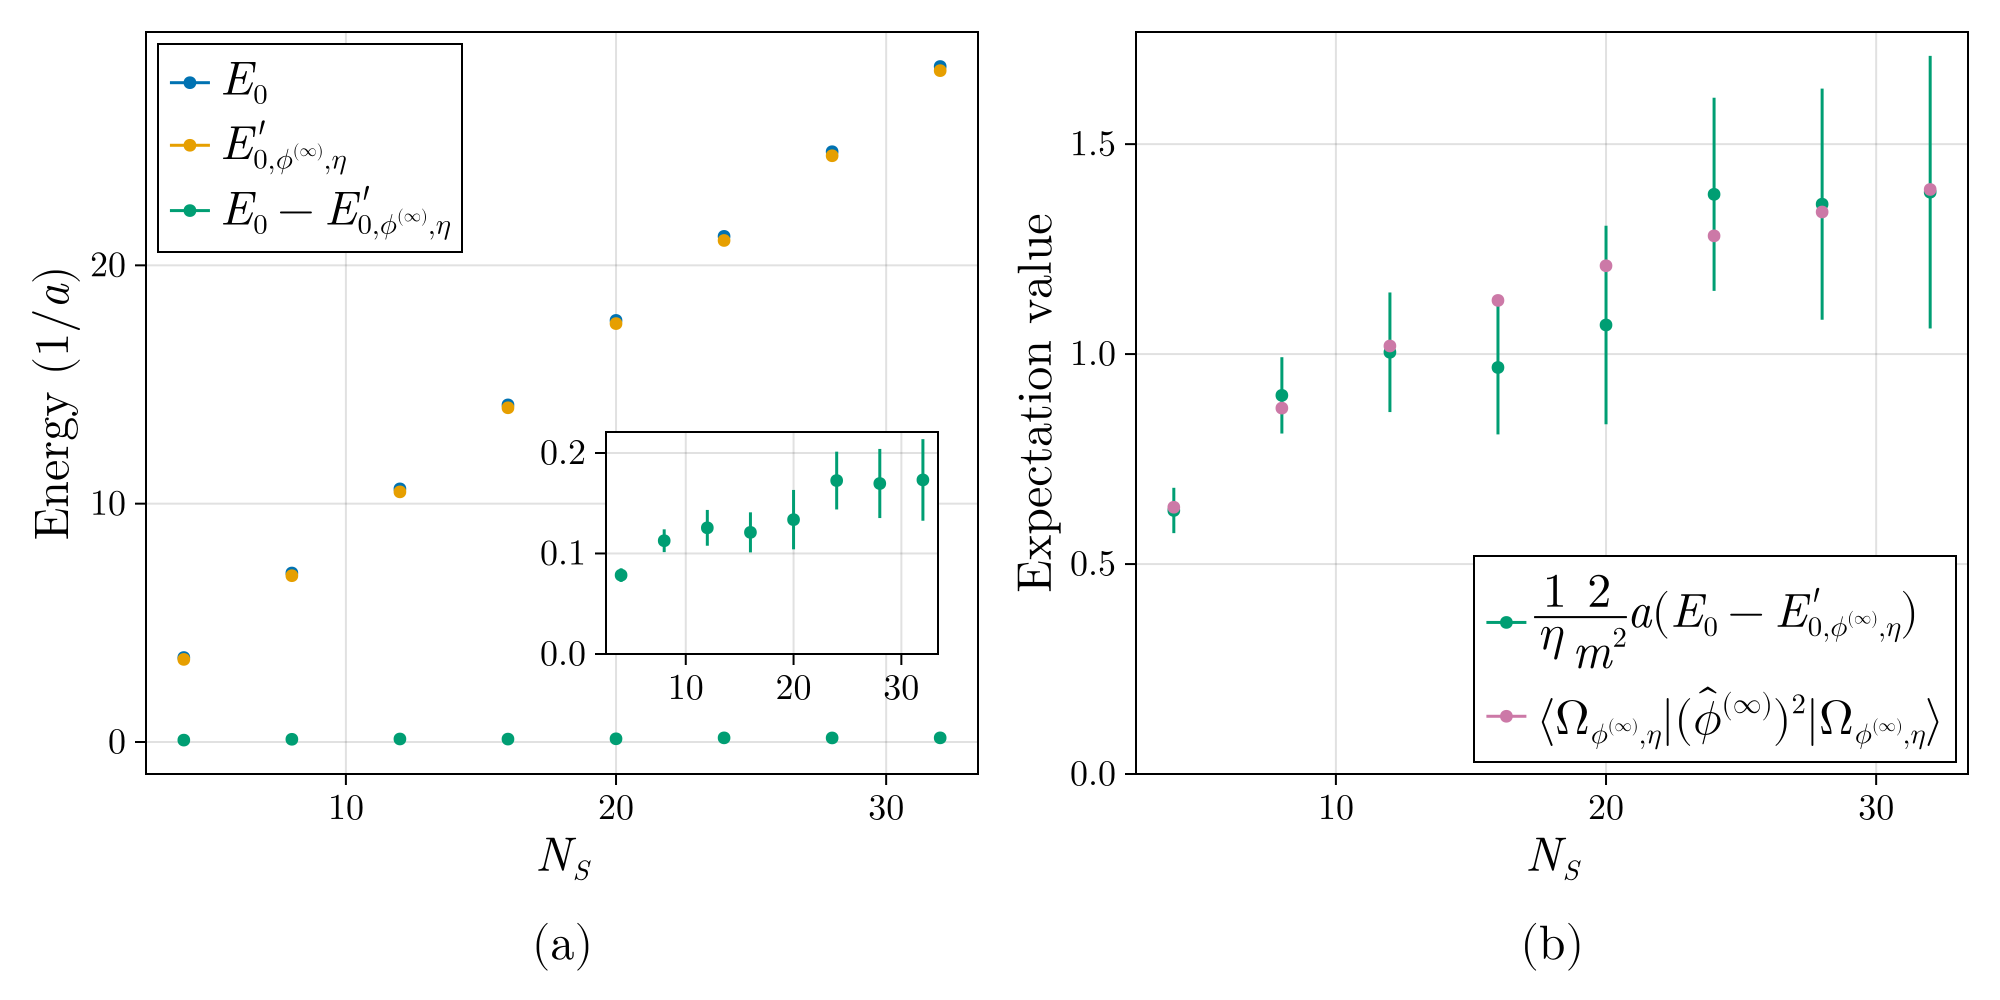

In [13]:
e_phi2max_phi2       = energy_from_phi2(phi2max_phi2_ls)
e_phi2max_phi2_delta = energy_from_phi2(phi2max_phi2_delta_ls)
e_phi2max_legend = L"\eta\frac{m_0^2}{2}\langle\Omega_{\phi^{(\infty)},\eta}|(\hat{\phi}^{(\infty)})^2 | \Omega_{\phi^{(\infty)},\eta}\rangle"

f = Figure(;size=(1000, 500))
ax1 = Axis(f[1, 1]; xlabel=L"N_S", ylabel=L"Energy ($1/a$)")

scatter!(ax1, Ns_list, energy_unmodified_ls; label=L"E_0")
errorbars!(ax1, Ns_list, energy_unmodified_ls, energy_unmodified_delta_ls, label=L"E_0")
scatter!(ax1, Ns_list, energy_phi2_ls; label=L"E'_{0,\phi^{(\infty)},\eta}")
errorbars!(ax1, Ns_list, energy_phi2_ls, energy_phi2_delta_ls; label=L"E'_{0,\phi^{(\infty)},\eta}")
scatter!(ax1, Ns_list, energy_unmodified_ls .- energy_phi2_ls; label=L"E_0 - E'_{0,\phi^{(\infty)},\eta}")
errorbars!(ax1, Ns_list, energy_unmodified_ls .- energy_phi2_ls, hypot.(energy_unmodified_delta_ls, energy_phi2_delta_ls); label=L"E_0 - E'_{0,\phi^{(\infty)},\eta}")

ax_inset = Axis(f[1,1]; width = Relative(0.4), height = Relative(0.3),
                halign = 0.92, valign = 0.23, yticks = WilkinsonTicks(3))
translate!(ax_inset.blockscene, 0, 0, 150)

scatter!(ax_inset, Ns_list, energy_unmodified_ls .- energy_phi2_ls; color=Cycled(3))
errorbars!(ax_inset, Ns_list, energy_unmodified_ls .- energy_phi2_ls, hypot.(energy_unmodified_delta_ls, energy_phi2_delta_ls); color=Cycled(3))
ylims!(ax_inset, (0, nothing))

axislegend(ax1; position= :lt, merge=true)



phi2_est = phi2bound_from_energy.(energy_unmodified_ls .- energy_phi2_ls)
phi2_est_delta = phi2bound_from_energy.(hypot.(energy_unmodified_delta_ls, energy_phi2_delta_ls)) # since this is a linear function
legend_energydiff = L"\frac{1}{\eta} \frac{2}{m^2} a (E_0 - E'_{0,\phi^{(\infty)},\eta})"
legend_phi2max    = L"\langle\Omega_{\phi^{(\infty)},\eta}|(\hat{\phi}^{(\infty)})^2 | \Omega_{\phi^{(\infty)},\eta}\rangle"

ax2 = Axis(f[1, 2]; xlabel=L"N_S", ylabel="Expectation value")
ylims!(ax2, (0, nothing))
scatter!(ax2, Ns_list, phi2_est; label=legend_energydiff, color=Cycled(3))
errorbars!(ax2, Ns_list, phi2_est, phi2_est_delta; label=legend_energydiff, color=Cycled(3))
scatter!(ax2, Ns_list, phi2max_phi2_ls; label=legend_phi2max, color=Cycled(4))
errorbars!(ax2, Ns_list, phi2max_phi2_ls, phi2max_phi2_delta_ls; label=legend_phi2max, color=Cycled(4))
axislegend(ax2; position= :rb, merge=true)

Label(f[2, 1], "(a)"; tellwidth=false)
Label(f[2, 2], "(b)"; tellwidth=false)

save(joinpath(fig_path, "$(plot_prefix)_energy_plot.pdf"), f)



f

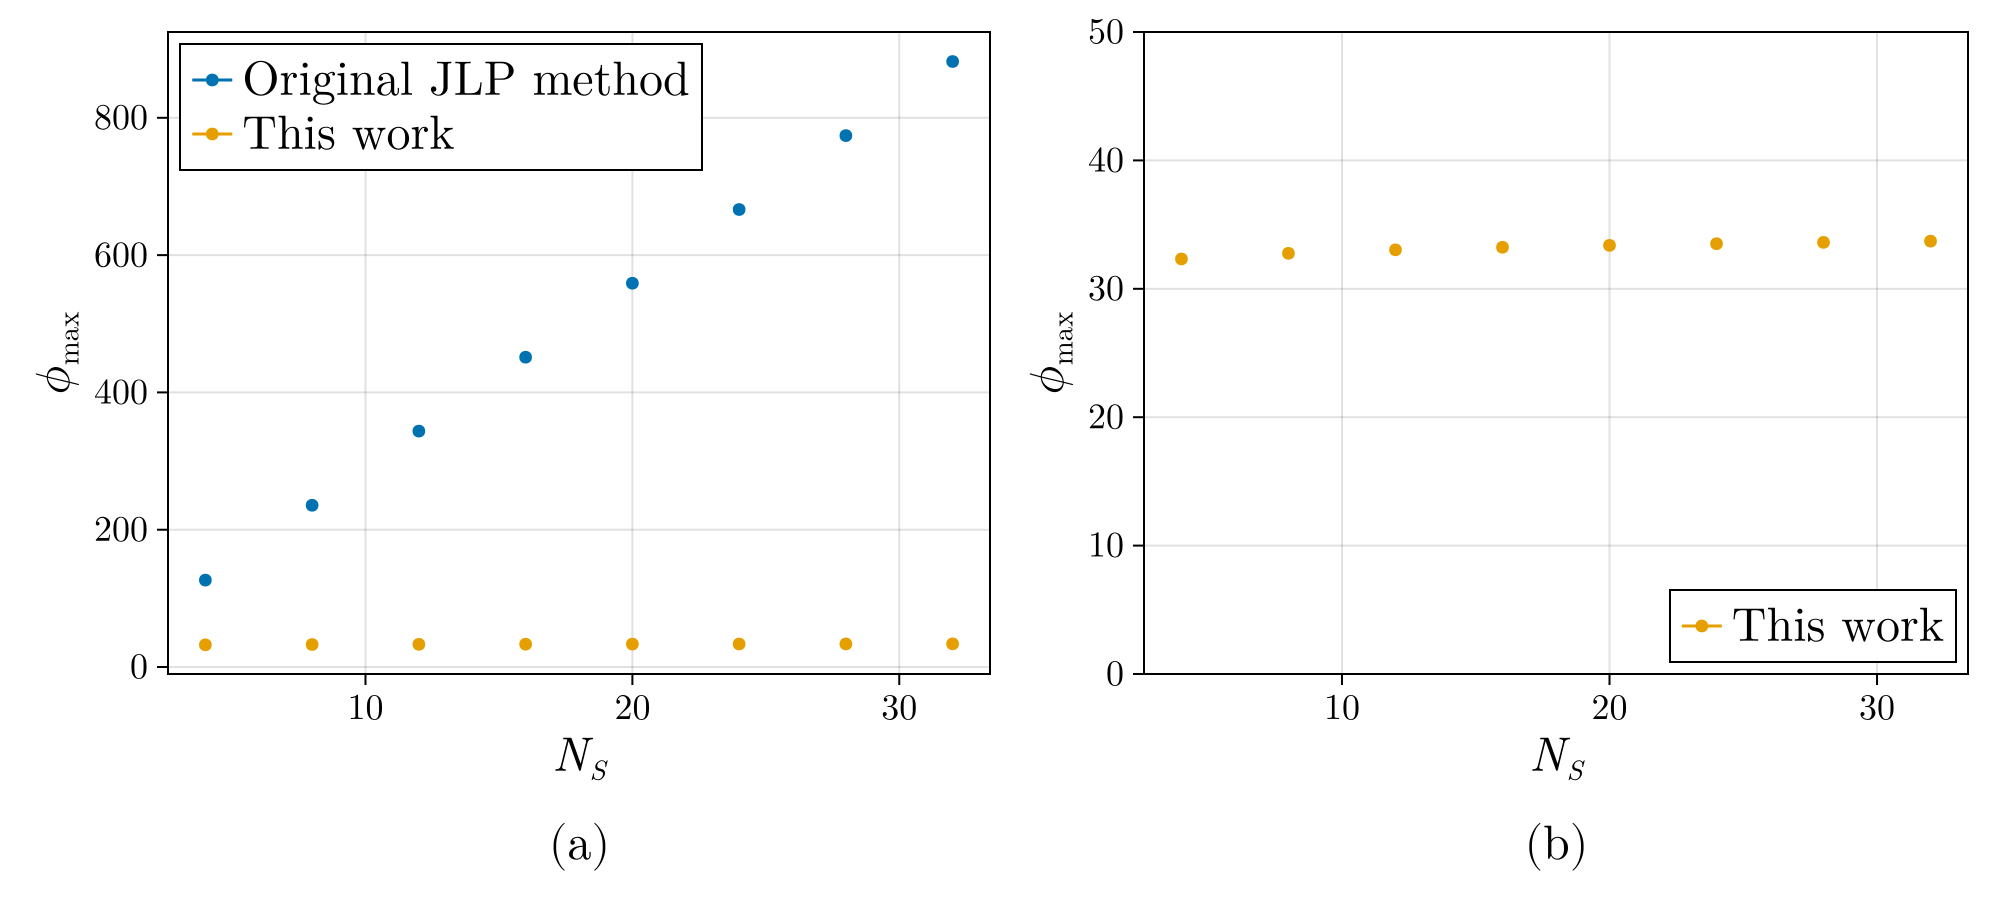

In [14]:
f = Figure(;size=(1000, 450))
e_free = 1.0
# Label(f[0, :], L"$E_\text{free}$ is %$e_free")




bound_phi2_naive         = phi2bound_from_energy.(energy_unmodified_ls .+ e_free; subtract_ratio = 1.0)
bound_phi2_naive_delta   = phi2bound_from_energy.(energy_unmodified_delta_ls; subtract_ratio = 1.0)
bound_phirms_naive       = sqrt.(bound_phi2_naive)
bound_phirms_naive_delta = bound_phi2_naive_delta ./ bound_phirms_naive / 2
volume_ls                = Ns_list
factor_naive_ls          = sqrt.(volume_ls ./ epsilon ) .+ 1
phi_trunc_naive          = factor_naive_ls .* bound_phirms_naive
phi_trunc_naive_delta    = factor_naive_ls .* bound_phirms_naive_delta


ΔE_upper              = energy_from_phi2.(phi2max_phi2_ls)
bound_phi2_im         = phi2bound_from_energy.(ΔE_upper .+ e_free)
bound_phi2_im_delta   = phi2max_phi2_delta_ls
bound_phirms_im       = sqrt.(bound_phi2_im)
bound_phirms_im_delta = bound_phi2_im_delta ./ bound_phirms_im / 2
factor_im_ls          = sqrt(1/epsilon) + 1
phi_trunc_im          = factor_im_ls .* bound_phirms_im
phi_trunc_im_delta    = factor_im_ls .* bound_phirms_im_delta


ylabel_compare = L"\phi_\text{max}"



# here, for the naive method, we need to multiple by sqrt(Volume) factor
ax1 = Axis(f[1, 1]; xlabel=L"N_S", ylabel=ylabel_compare)
scatter!(ax1, Ns_list, phi_trunc_naive; label="Original JLP method")
errorbars!(ax1, Ns_list, phi_trunc_naive, phi_trunc_naive_delta; label="Original JLP method")
scatter!(ax1, Ns_list, phi_trunc_im; label="This work")
errorbars!(ax1, Ns_list,  phi_trunc_im, phi_trunc_im_delta; label="This work")
axislegend(ax1; position=:lt, merge=true)



# here, for the naive method, we need to multiple by sqrt(Volume) factor
ax2 = Axis(f[1, 2]; xlabel=L"N_S", ylabel=ylabel_compare)
ylims!(ax2, (0, 50))
scatter!(ax2, Ns_list, phi_trunc_im; label="This work", color=Cycled(2))
errorbars!(ax2, Ns_list, phi_trunc_im, phi_trunc_im_delta; label="This work", color=Cycled(2))
axislegend(ax2; position=:rb, merge=true)

Label(f[2, 1], "(a)"; tellwidth=false)
Label(f[2, 2], "(b)"; tellwidth=false)

save(joinpath(fig_path, "$(plot_prefix)_bound_compare.pdf"), f)



f

In [15]:
function pi_from_energy(energy)
    return sqrt(2 * energy)
end

pi_from_energy (generic function with 1 method)

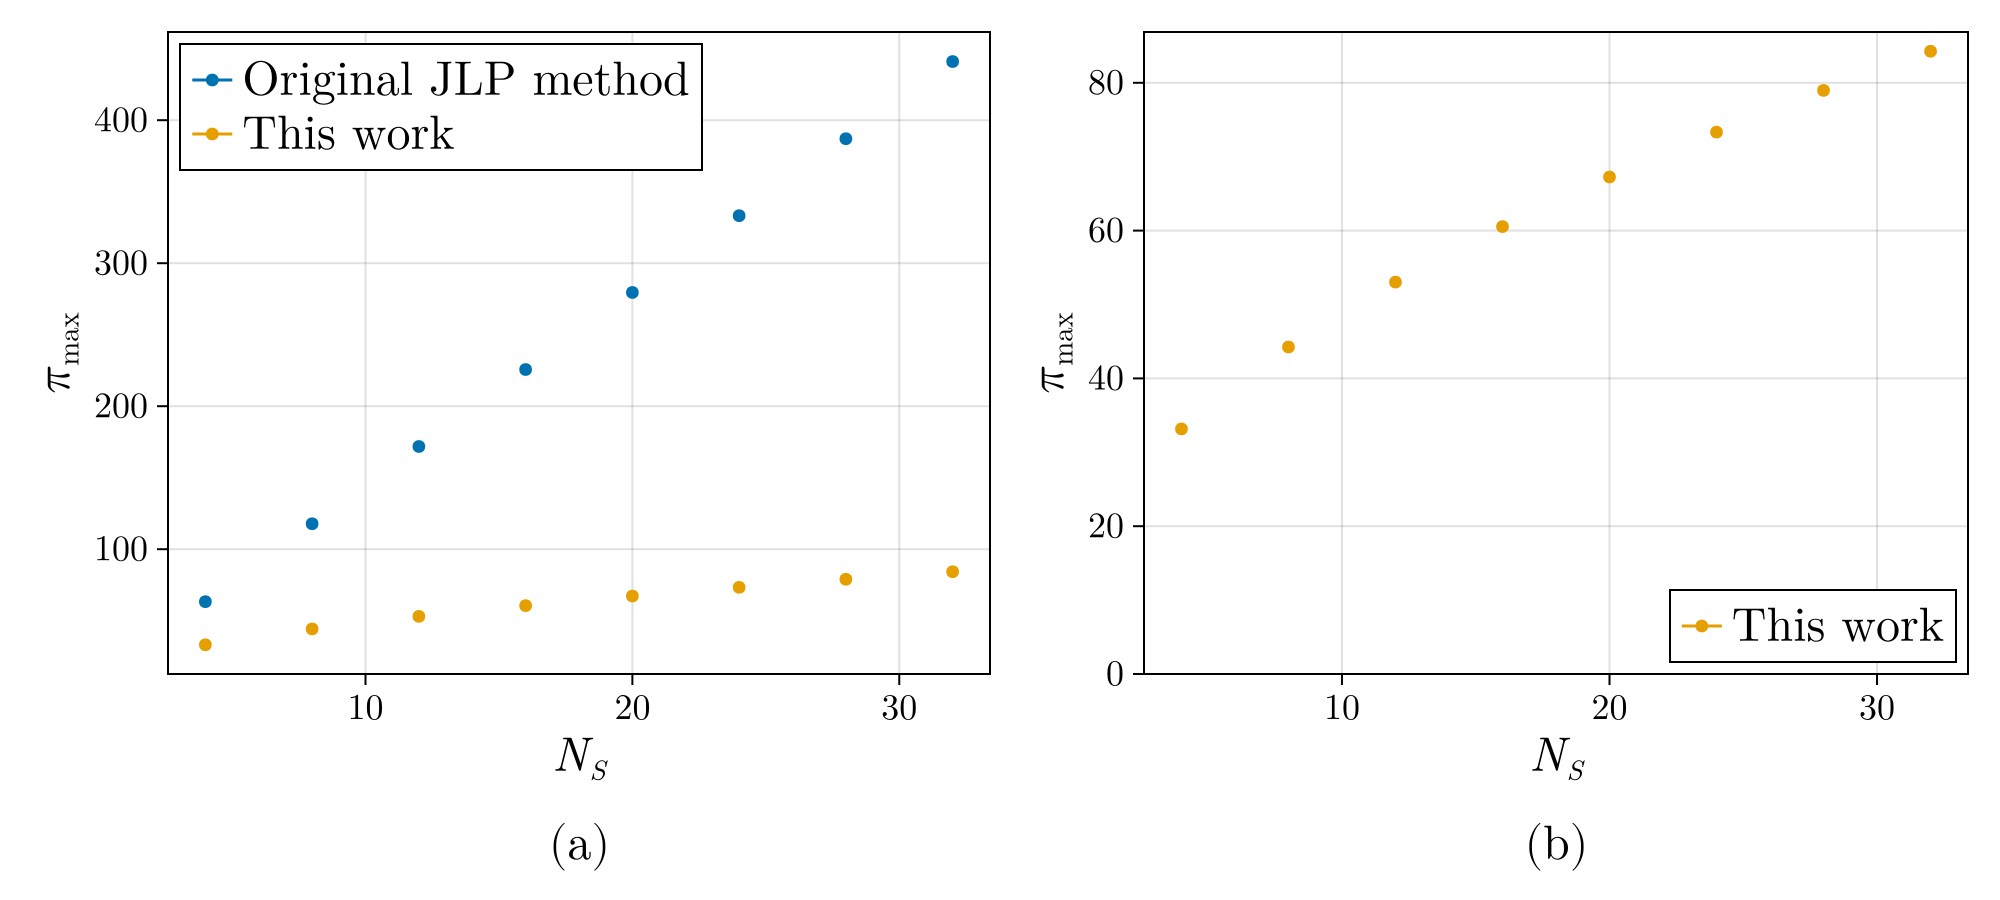

In [16]:
f = Figure(;size=(1000, 450))
e_free = 1.0
V_ls = Ns_list

pi_ls = pi_from_energy.(energy_unmodified_ls .+ e_free)
pi_delta_ls = 1 ./ sqrt.(2 .* energy_unmodified_ls) .* energy_unmodified_delta_ls

pi_trunc_naive = (sqrt.(V_ls ./ epsilon) .+ 1) .* pi_ls
pi_trunc_naive_delta = (sqrt.(V_ls ./ epsilon) .+ 1) .* pi_delta_ls

pi_trunc_im = (sqrt(1 / epsilon) + 1) .* pi_ls
pi_trunc_im_delta = (sqrt(1 / epsilon) + 1) .* pi_delta_ls

ylabel_compare = L"\pi_\text{max}"


ax1 = Axis(f[1, 1]; xlabel=L"N_S", ylabel=ylabel_compare)
scatter!(ax1, Ns_list, pi_trunc_naive; label="Original JLP method")
errorbars!(ax1, Ns_list, pi_trunc_naive, pi_trunc_naive_delta; label="Original JLP method")
scatter!(ax1, Ns_list, pi_trunc_im; label="This work")
errorbars!(ax1, Ns_list, pi_trunc_im, pi_trunc_im_delta; label="This work")
axislegend(ax1; position=:lt, merge=true)


ax2 = Axis(f[1, 2]; xlabel=L"N_S", ylabel=ylabel_compare)
ylims!(ax2, (0, nothing))
scatter!(ax2, Ns_list, pi_trunc_im; label="This work", color=Cycled(2))
errorbars!(ax2, Ns_list, pi_trunc_im, pi_trunc_im_delta; label="This work", color=Cycled(2))
axislegend(ax2; position=:rb, merge=true)

Label(f[2, 1], "(a)"; tellwidth=false)
Label(f[2, 2], "(b)"; tellwidth=false)

save(joinpath(fig_path, "$(plot_prefix)_pi_bound_compare.pdf"), f)

f


In [17]:
i = 2
println("At N_S = $(Ns_list[i])")
println("We have naive phi trunc as $(phi_trunc_naive[i])")
println("And improved phi trunc at $(phi_trunc_im[i])")
ratio = phi_trunc_naive[i] / phi_trunc_im[i]
println("With saving factor being roughly $(ratio)")

At N_S = 8
We have naive phi trunc as 235.58103309246277
And improved phi trunc at 32.76328172095335
With saving factor being roughly 7.190397930797019


In [18]:
i = 8
println("At N_S = $(Ns_list[i])")
println("We have naive phi trunc as $(phi_trunc_naive[i])")
println("And improved phi trunc at $(phi_trunc_im[i])")
ratio = phi_trunc_naive[i] / phi_trunc_im[i]
println("With saving factor being roughly $(ratio)")

At N_S = 32
We have naive phi trunc as 882.0070995380776
And improved phi trunc at 33.71110489929379
With saving factor being roughly 26.1636959741582


In [19]:
i = 2
println("At N_S = $(Ns_list[i])")
println("We have naive pi trunc as $(pi_trunc_naive[i])")
println("And improved pi trunc at $(pi_trunc_im[i])")
ratio = pi_trunc_naive[i] / pi_trunc_im[i]
println("With saving factor being roughly $(ratio)")

At N_S = 8
We have naive pi trunc as 117.79051654623139
And improved pi trunc at 44.24544736181012
With saving factor being roughly 2.662206477041991


In [20]:
i = 8
println("At N_S = $(Ns_list[i])")
println("We have naive pi trunc as $(pi_trunc_naive[i])")
println("And improved pi trunc at $(pi_trunc_im[i])")
ratio = pi_trunc_naive[i] / pi_trunc_im[i]
println("With saving factor being roughly $(ratio)")

At N_S = 32
We have naive pi trunc as 441.0035497690388
And improved pi trunc at 84.26544840677832
With saving factor being roughly 5.2335038631748905
